In [2]:
import os
import sys

import math
import time
import datetime
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
# from YourDataset import YourDataset  # Import your custom dataset here
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from torchinfo import summary
import torchprofile

from utils.architecture import Unet
from utils.diffusion import ElucidatedDiffusion

torch.manual_seed(23)
import pickle

DTYPE = torch.float32

scaler = GradScaler()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 200
plt.rcParams["font.family"] = "serif"

import scipy.stats as stats
#from sklearn.decomposition import TruncatedSVD

Using device: cuda


In [3]:
def error_metric(pred,true, Par):
    #re-normalize
    # true = true*Par['out_scale'] + Par['out_shift']
    # true = true*Par['out_scale'] + Par['out_shift']
    return torch.norm(true-pred, p=2)/torch.norm(true, p=2)

class MyDataset(Dataset):
    def __init__(self, x, y, transform=None):
        self.x = x
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x_sample = self.x[idx]
        y_sample = self.y[idx]

        if self.transform:
            x_sample, y_sample = self.transform(x_sample, y_sample)

        return x_sample, y_sample
    
def preprocess(x,y, Par):
    x = sliding_window_view(x[:,Par['lb']-1:,:,:], window_shape=Par['lf'], axis=1 ).transpose(0,1,4,2,3).reshape(-1,Par['lf'],Par['nx'], Par['ny'])
    y = sliding_window_view(y[:,Par['lb']-1:,:,:], window_shape=Par['lf'], axis=1 ).transpose(0,1,4,2,3).reshape(-1,Par['lf'],Par['nx'], Par['ny'])

    print('x: ', x.shape)
    print('y: ', y.shape)
    print()
    return x,y


In [11]:
res = 128
begin_time = time.time()

x_train = np.load("../TRAIN_PRED.npy")
y_train = np.load("../TRAIN_TRUE.npy")

x_val = np.load("../VAL_PRED.npy")
y_val = np.load("../VAL_TRUE.npy")

x_test = np.load("../TEST_PRED.npy")
y_test = np.load("../TEST_TRUE.npy")


inp_min = np.min(x_train)
inp_max = np.max(x_train)
out_min = np.min(y_train)
out_max = np.max(y_train)


Par = {"inp_shift" : torch.tensor(inp_min, dtype=DTYPE, device=device),
       "inp_scale" : torch.tensor(inp_max - inp_min, dtype=DTYPE, device=device),
       "out_shift" : torch.tensor(out_min, dtype=DTYPE, device=device),
       "out_scale" : torch.tensor(out_max - out_min, dtype=DTYPE, device=device),
       "nx"        : x_train.shape[2],
       "ny"        : x_train.shape[3],
       "nf"        : 1,
       "lb"        : 1,
       "lf"        : 1,
       "num_epochs": 1000
       }

# Normalizing the data to [0,1]
shift = Par['inp_shift'].detach().cpu().numpy()
scale = Par['inp_scale'].detach().cpu().numpy()
x_train = (x_train - shift)/scale
x_val = (x_val - shift)/scale
x_test = (x_test - shift)/scale

shift = Par['out_shift'].detach().cpu().numpy()
scale = Par['out_scale'].detach().cpu().numpy()
y_train = (y_train - shift)/scale
y_val = (y_val - shift)/scale
y_test = (y_test - shift)/scale

Par["sigma_data"] = np.std(y_train)

# Traj splitting
begin_time = time.time()
print('\nTrain Dataset')
x_train, y_train = preprocess(x_train, y_train, Par)
print('\nValidation Dataset')
x_val, y_val = preprocess(x_val, y_val, Par)
print('\nTest Dataset')
x_test, y_test = preprocess(x_test, y_test, Par)
print(f"Data Preprocess Time: {time.time() - begin_time:.1f}s")

# 此时数据已经从5条轨迹展开为450帧

test_num = min(50, len(x_test))
x_test = x_test[:test_num]
y_test = y_test[:test_num]

print("After reduction:", x_test.shape, y_test.shape)

print(f"Data Preprocess Time: {time.time() - begin_time:.1f}s")

Par.update({"channels"       : x_train.shape[1],
            "self_condition" : True
            })

print("Par")
with open('Par.pkl', 'wb') as f:
    pickle.dump(Par, f)

x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

x_val_tensor   = torch.tensor(x_val,   dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val,   dtype=torch.float32)

x_test_tensor  = torch.tensor(x_test,  dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32)

train_dataset = MyDataset(x_train_tensor, y_train_tensor)
val_dataset = MyDataset(x_val_tensor, y_val_tensor)
test_dataset = MyDataset(x_test_tensor, y_test_tensor)

# Define data loaders
train_batch_size = 4 #16
val_batch_size   = 1
test_batch_size  = 1
train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=val_batch_size)
test_loader = DataLoader(test_dataset, batch_size=test_batch_size)


Train Dataset
x:  (3600, 1, 64, 64)
y:  (3600, 1, 64, 64)


Validation Dataset
x:  (450, 1, 64, 64)
y:  (450, 1, 64, 64)


Test Dataset
x:  (450, 1, 64, 64)
y:  (450, 1, 64, 64)

Data Preprocess Time: 0.0s
After reduction: (50, 1, 64, 64) (50, 1, 64, 64)
Data Preprocess Time: 0.0s
Par


In [12]:
# 建立与 train_dm.py 完全相同的去噪 U-Net
net = Unet(
    dim=16,
    dim_mults=(1, 2, 4, 8),
    channels=Par["channels"],
    self_condition=Par["self_condition"],
    flash_attn=False
).to(device).to(torch.float32)

summary(net, input_size=((1,) + x_train.shape[1:], (1,)))

# 将去噪 U-Net 放入扩散模型
model = ElucidatedDiffusion(
    net,
    channels=Par["channels"],
    image_size_h=Par["nx"],
    image_size_w=Par["ny"],
    sigma_data=Par["sigma_data"]
).to(device)

# 加载刚才训练得到的最佳DM权重
path_model = "models_reduced/best_model.pt"

model.load_state_dict(
    torch.load(path_model, map_location=device)
)

model.eval()
print("DM model loaded successfully")

DM model loaded successfully


In [13]:
with torch.no_grad():
    for batch_id, (l_fidel, h_fidel) in enumerate(
        tqdm(test_loader, desc="Sampling test frames"),
        start=1
    ):
        with autocast():
            pred = model.sample(
                l_fidel.to(device),
                num_sample_steps=32
            )
            loss = error_metric(
                pred,
                h_fidel.to(device),
                Par
            )

        test_loss += loss.item()
        l_fidel_ls.append(l_fidel.cpu())
        y_true_ls.append(h_fidel.cpu())
        y_pred_ls.append(pred.detach().cpu())

        print(f"Finished sampling frame {batch_id}/{len(test_loader)}")

Sampling test frames:   2%|▏         | 1/50 [00:03<02:45,  3.37s/it]

Finished sampling frame 1/50


Sampling test frames:   4%|▍         | 2/50 [00:06<02:31,  3.15s/it]

Finished sampling frame 2/50


Sampling test frames:   6%|▌         | 3/50 [00:10<02:40,  3.42s/it]

...

Finished sampling frame 48/50


Sampling test frames:  98%|█████████▊| 49/50 [02:47<00:03,  3.40s/it]

Finished sampling frame 49/50


Sampling test frames: 100%|██████████| 50/50 [02:51<00:00,  3.43s/it]

Finished sampling frame 50/50


In [15]:
# 合并结果，并统一移动到CPU
y_true = torch.cat(
    [x.detach().cpu() for x in y_true_ls],
    dim=0
).numpy()[:, 0]

y_pred = torch.cat(
    [x.detach().cpu() for x in y_pred_ls],
    dim=0
).numpy()[:, 0]

y_no = torch.cat(
    [x.detach().cpu() for x in l_fidel_ls],
    dim=0
).numpy()[:, 0]

# 增加一维轨迹维度
# 形状从 (50, 64, 64) 变为 (1, 50, 64, 64)
y_true = y_true[None, ...]
y_pred = y_pred[None, ...]
y_no   = y_no[None, ...]

# 暂时把第一帧作为初始参考场
x_true = y_true[:, :1].copy()

# 从 [0,1] 恢复到原始物理数值范围
out_scale = Par["out_scale"].detach().cpu().numpy()
out_shift = Par["out_shift"].detach().cpu().numpy()
inp_scale = Par["inp_scale"].detach().cpu().numpy()
inp_shift = Par["inp_shift"].detach().cpu().numpy()

y_true = y_true * out_scale + out_shift
y_pred = y_pred * out_scale + out_shift
y_no   = y_no * inp_scale + inp_shift

print("x_true:", x_true.shape)
print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)
print("y_no:", y_no.shape)

x_true: (1, 1, 64, 64)
y_true: (1, 269, 64, 64)
y_pred: (1, 269, 64, 64)
y_no: (1, 269, 64, 64)


In [16]:
def compute_power(true, pred, inp):
    BS, nt, nx, ny = true.shape

    true = torch.tensor(true, device=device, dtype=DTYPE)
    pred = torch.tensor(pred, device=device, dtype=DTYPE)
    inp = torch.tensor(inp, device=device, dtype=DTYPE)
    
    # Compute the Fourier transforms and amplitude squared for both true and pred
    fourier_true = torch.fft.fftn(true, dim=(-2, -1))
    fourier_pred = torch.fft.fftn(pred, dim=(-2, -1))
    fourier_inp  = torch.fft.fftn(inp , dim=(-2, -1))

    # Get the squared amplitudes
    amplitudes_true = torch.abs(fourier_true) ** 2
    amplitudes_pred = torch.abs(fourier_pred) ** 2
    amplitudes_inp = torch.abs(fourier_inp) ** 2

    # Create the k-frequency grids
    kfreq_y = torch.fft.fftfreq(ny) * ny
    kfreq_x = torch.fft.fftfreq(nx) * nx
    kfreq2D_x, kfreq2D_y = torch.meshgrid(kfreq_x, kfreq_y, indexing='ij')
    
    # Compute the wavenumber grid
    knrm = torch.sqrt(kfreq2D_x ** 2 + kfreq2D_y ** 2).to(true.device)
    
    # Define the bins for the wavenumber
    kbins = torch.arange(0.5, nx // 2 + 1, 1.0, device=true.device)
    
    # Digitize knrm to bin indices
    knrm_flat = knrm.flatten()
    bin_indices = torch.bucketize(knrm_flat, kbins)

    # Reshape and flatten the amplitudes
    amplitudes_true_flat = amplitudes_true.view(BS, nt, nx * ny)
    amplitudes_pred_flat = amplitudes_pred.view(BS, nt, nx * ny)
    amplitudes_inp_flat  = amplitudes_inp.view(BS, nt, nx * ny)

    # Initialize Abins
    Abins_true = torch.zeros((BS, nt, len(kbins) - 1), device=true.device)
    Abins_pred = torch.zeros((BS, nt, len(kbins) - 1), device=pred.device)
    Abins_inp  = torch.zeros((BS, nt, len(kbins) - 1), device= inp.device)

    # Vectorized binning: sum up the values in each bin
    for bin_idx in range(1, len(kbins)):
        mask = (bin_indices == bin_idx).unsqueeze(0).unsqueeze(0)  # Create a mask for each bin
        Abins_true[:, :, bin_idx - 1] = (amplitudes_true_flat * mask).sum(dim=-1) / mask.sum(dim=-1)
        Abins_pred[:, :, bin_idx - 1] = (amplitudes_pred_flat * mask).sum(dim=-1) / mask.sum(dim=-1)
        Abins_inp[:,  :, bin_idx - 1] = (amplitudes_inp_flat  * mask).sum(dim=-1) / mask.sum(dim=-1)

    # Scale the binned amplitudes
    scaling_factor = torch.pi * (kbins[1:] ** 2 - kbins[:-1] ** 2)
    Abins_true *= scaling_factor
    Abins_pred *= scaling_factor
    Abins_inp  *= scaling_factor

    Abins_true = torch.log(Abins_true)
    Abins_pred = torch.log(Abins_pred)
    Abins_inp = torch.log(Abins_inp)
    

    return Abins_true.detach().cpu().numpy(), Abins_pred.detach().cpu().numpy(), Abins_inp.detach().cpu().numpy()

def field_get_err(true, pred):
    return np.mean( np.mean( (true-pred)**2, axis=(2,3) )/np.mean(true**2, axis=(2,3)) )
    # return np.mean(  np.sqrt(np.mean( (true-pred)**2, axis=(2,3) ))  )
    # true = true.reshape(-1,)
    # pred = pred.reshape(-1,)
    # # err = np.linalg.norm(true - pred, ord=2)/np.linalg.norm(true, ord=2)
    # err = np.mean( (true-pred)**2 )/np.mean(true**2)
    # return err

 

def spec_get_err(true, pred):
    return np.mean( np.mean( (true-pred)**2, axis=(1,2)  ) /np.mean(true**2, axis=(1,2) ) )
    # return np.mean(  np.sqrt(np.mean( (true-pred)**2, axis=(1,2) ))  )
    # true = true.reshape(-1,)
    # pred = pred.reshape(-1,)
    # # err = np.linalg.norm(true - pred, ord=2)/np.linalg.norm(true, ord=2)
    # err = np.mean( (true-pred)**2 )/np.mean(true**2)
    # return err

spec_true, spec_pred, spec_no = compute_power(
    y_true, y_pred, y_no
)

# 流场误差
field_err_dm = field_get_err(y_true, y_pred)
field_err_no = field_get_err(y_true, y_no)

print(f"Field relative L2 error, NO    : {field_err_no:.4e}")
print(f"Field relative L2 error, NO+DM : {field_err_dm:.4e}")

# 能谱误差
spec_err_dm = spec_get_err(spec_true, spec_pred)
spec_err_no = spec_get_err(spec_true, spec_no)

print(f"Spectrum relative L2 error, NO    : {spec_err_no:.4e}")
print(f"Spectrum relative L2 error, NO+DM : {spec_err_dm:.4e}")

Field relative L2 error, NO    : 2.1166e-01
Field relative L2 error, NO+DM : 2.7488e-01
Spectrum relative L2 error, NO    : 1.2896e-02
Spectrum relative L2 error, NO+DM : 1.1653e-02


In [17]:
# 创建结果保存文件夹
result_dir = "results_reduced"
os.makedirs(result_dir, exist_ok=True)

# 保存数据
np.save(os.path.join(result_dir, "x_true.npy"), x_true)
np.save(os.path.join(result_dir, "y_true.npy"), y_true)
np.save(os.path.join(result_dir, "y_no.npy"), y_no)
np.save(os.path.join(result_dir, "y_dm.npy"), y_pred)

print("Results saved to:", os.path.abspath(result_dir))
print("x_true:", x_true.shape)
print("y_true:", y_true.shape)
print("y_no:", y_no.shape)
print("y_dm:", y_pred.shape)

Results saved to: e:\AI_Project\NeuralOperator_DiffusionModel\case_1_kolmogorov\no_dm\unet\dm\results_reduced
x_true: (1, 1, 64, 64)
y_true: (1, 269, 64, 64)
y_no: (1, 269, 64, 64)
y_dm: (1, 269, 64, 64)


In [18]:
# 只使用第一条测试轨迹的前50个预测时刻
n_plot = min(50, y_true.shape[1])

y_true = y_true[:, :n_plot]
y_no   = y_no[:, :n_plot]
y_pred = y_pred[:, :n_plot]

# 原始轨迹 T=10，共100个时间步
dt = 10 / 100

# NO使用前10帧，预测从第11帧开始
start_step = 10
t_ls = (start_step + np.arange(n_plot)) * dt

print("Number of plotted frames:", n_plot)
print("Time range:", t_ls[0], "to", t_ls[-1])
print("t_ls shape:", t_ls.shape)

Number of plotted frames: 50
Time range: 1.0 to 5.9
t_ls shape: (50,)


k_nq: 32.0
Selected frame indices: [ 0 12 24 36 49]
Selected times: [1.  2.2 3.4 4.6 5.9]
Selected data shape: (5, 64, 64)


C:\Users\R9000p\AppData\Local\Temp\ipykernel_10984\1512021395.py:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1], pad=1.5, w_pad=0., h_pad=0.)


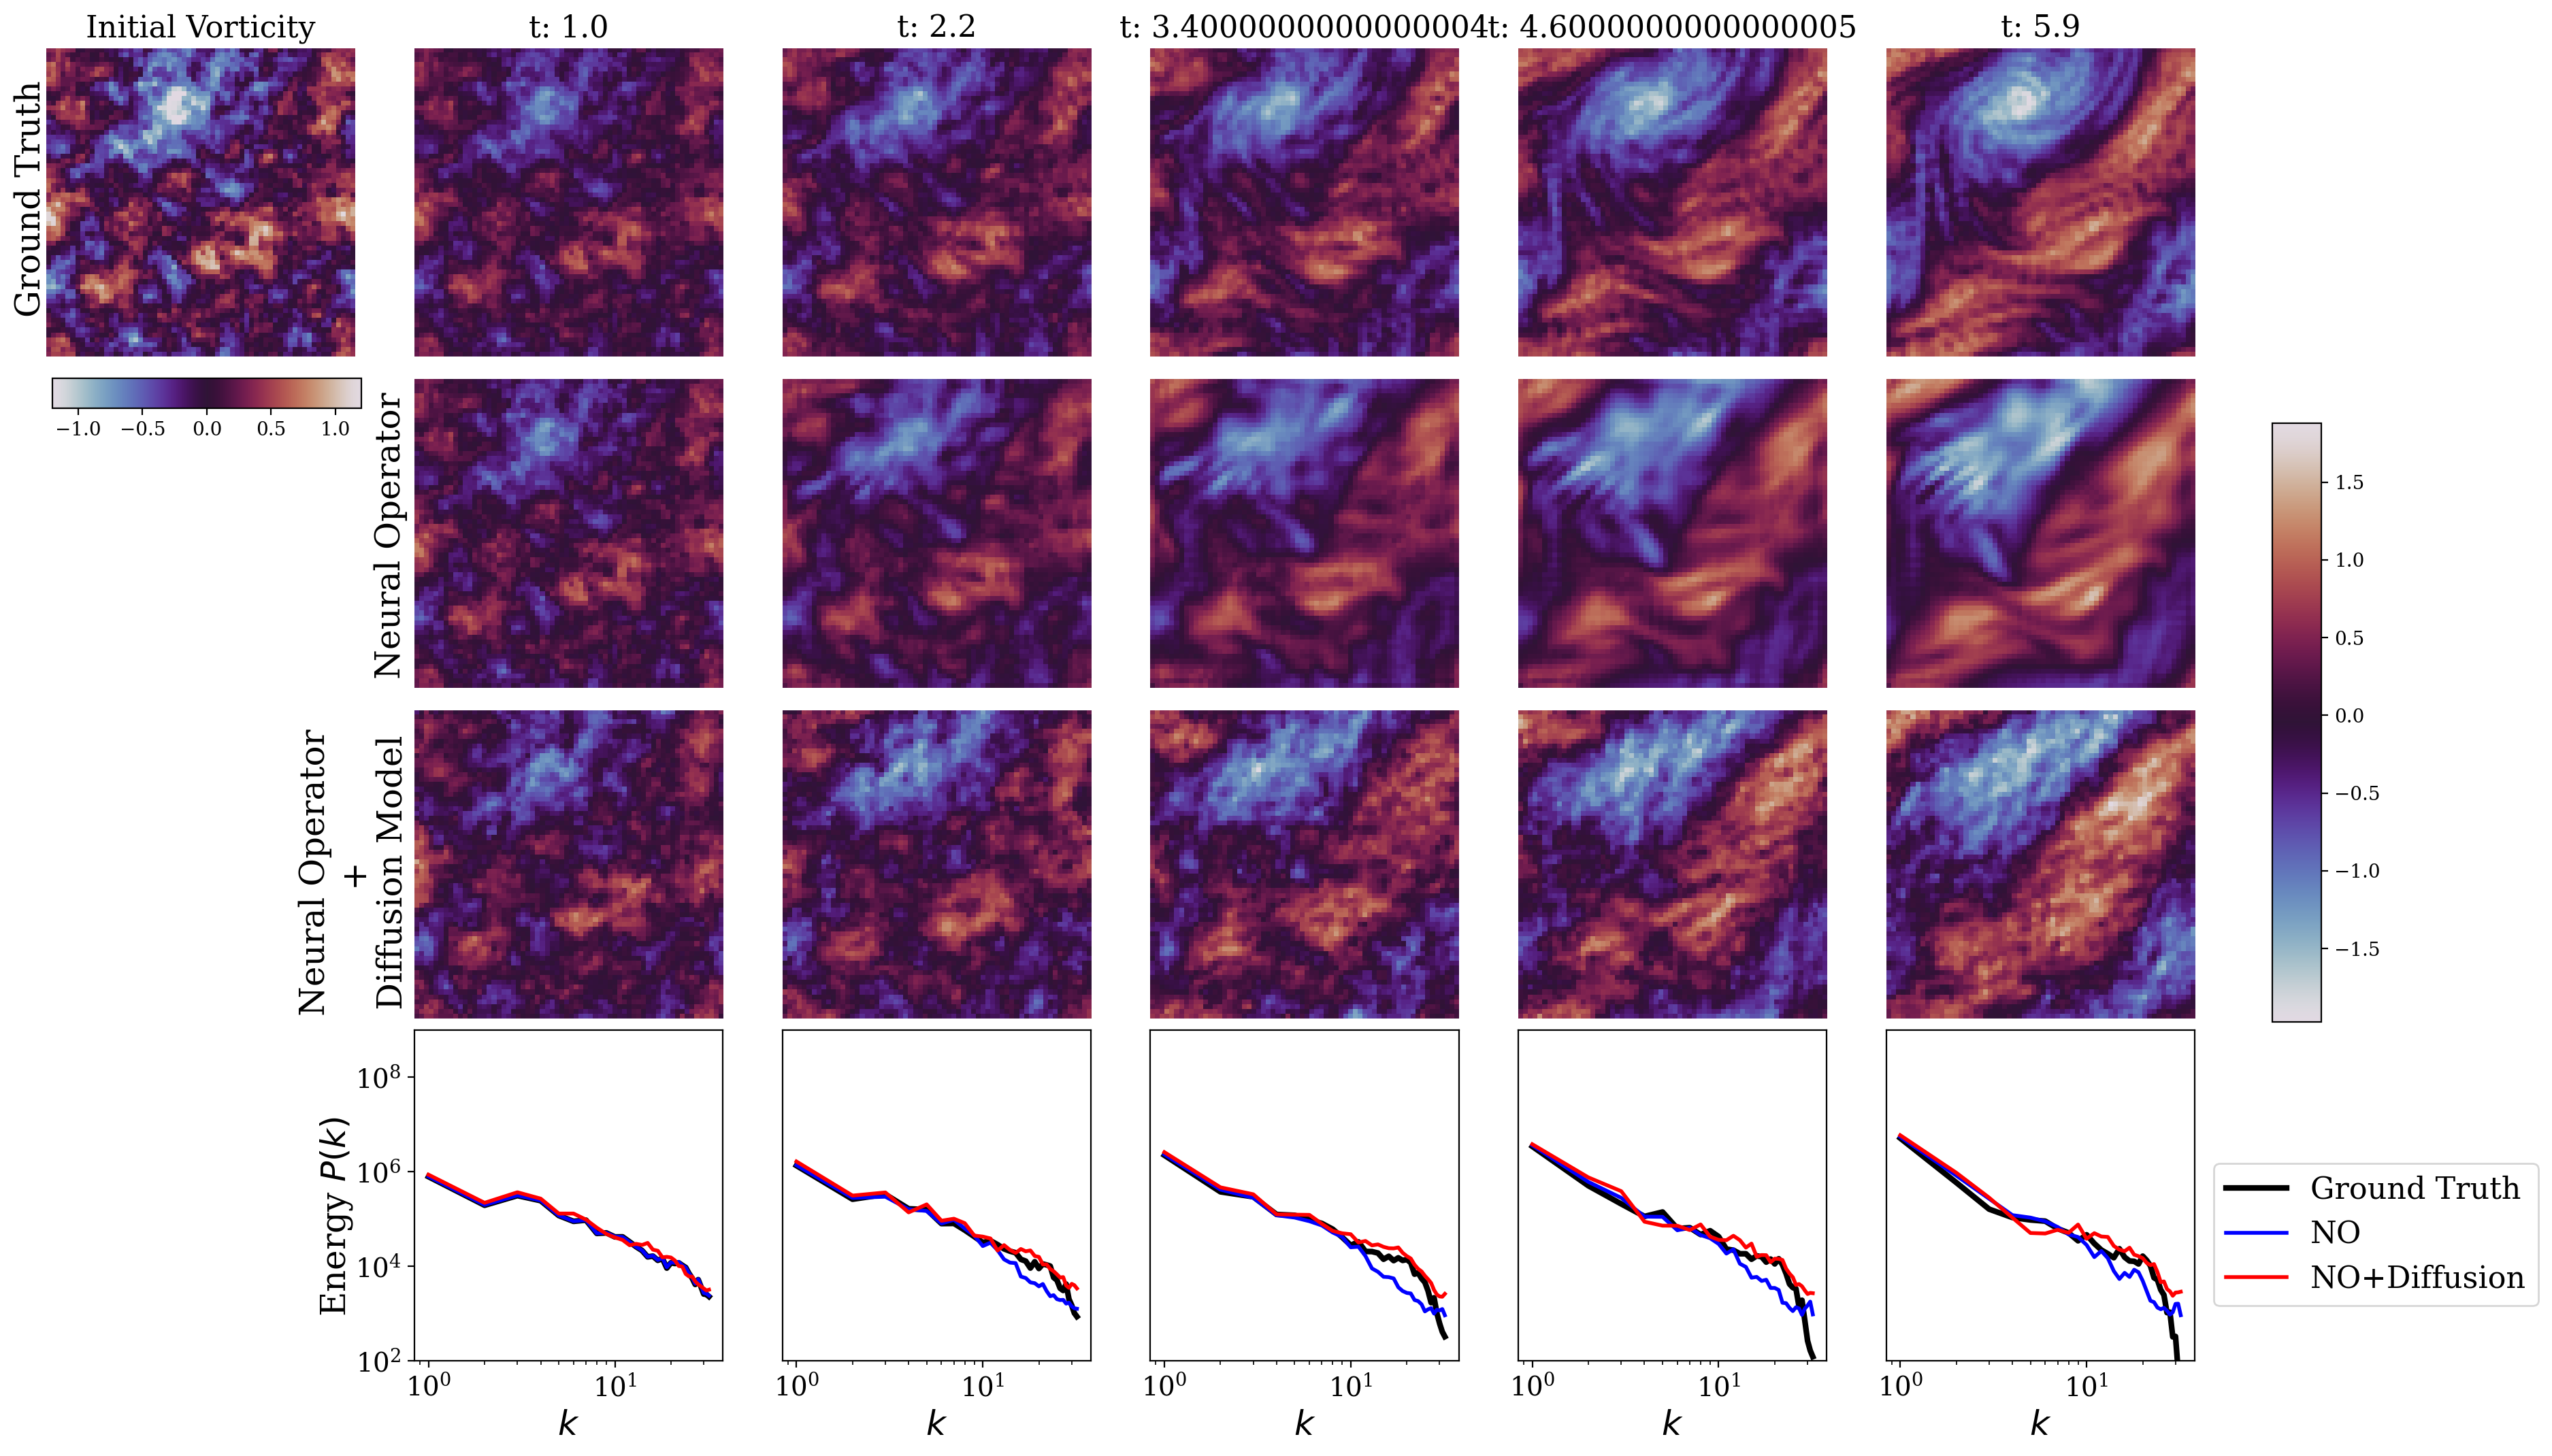

In [20]:
L = 2*np.pi
N = np.min(y_true.shape[2:])
delta_x = L/N
k_nq = np.pi/delta_x
print(f"k_nq: {k_nq}")

# 当前整理的数据只有1条轨迹，所以只能使用 sample_id=0
sample_id = 0

# 从50帧中均匀选取5个时刻
frame_indices = np.linspace(
    0,
    y_true.shape[1] - 1,
    5,
    dtype=int
)

true = y_true[sample_id, frame_indices]
pred1 = y_no[sample_id, frame_indices]       # NO结果
pred2 = y_pred[sample_id, frame_indices]     # NO+DM结果
time_ls = t_ls[frame_indices]

# 使用真实序列第一帧作为参考场
init = y_true[sample_id, 0]

print("Selected frame indices:", frame_indices)
print("Selected times:", time_ls)
print("Selected data shape:", true.shape)

CMAP = "twilight"

def mse(a, b):
    return np.mean((a - b) ** 2)
    
def rel_l2(T, P):
    T = torch.tensor(T, dtype=DTYPE)
    P = torch.tensor(P, dtype=DTYPE)
    return torch.norm(T-P, p=2)/torch.norm(T, p=2).cpu().numpy()

# Create the figure and axis
fig, axes = plt.subplots(4, 6, figsize=(18, 11))

cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])  # Colorbar axis

# Find the min and max values for colorbar
vmin = min(true.min(), pred1.min(), pred2.min())
vmax = max(true.max(), pred1.max(), pred2.max())

for ax in axes[1:, 0]:  # This loops over the first column from the second row onwards
    ax.axis('off')  # Turn these axes off as they are not used

# Plot the images
for i1 in range(6):
    if i1==0:
        # im = axes[0, i1].imshow(init, vmin=init.min(), vmax=init.max(), cmap=CMAP)
        im = axes[0, i1].imshow(init, vmin=-1.2, vmax=1.2, cmap=CMAP)
        axes[0, i1].set_title(f'Initial Vorticity', fontsize=16)
        axes[0, i1].axis('off') 
        cbar_init_ax = fig.add_axes([0.014, 0.71, 0.126, 0.02])  # (left, bottom, width, height)
        fig.colorbar(im, cax=cbar_init_ax, orientation='horizontal')
        continue

    i = i1-1
    
    # Ground truth row
    im = axes[0, i1].imshow(true[i], vmin=vmin, vmax=vmax, cmap=CMAP)
    axes[0, i1].set_title(f't: {time_ls[i]}', fontsize=16)
    axes[0, i1].axis('off')

    # Prediction 1 row
    im = axes[1, i1].imshow(pred1[i], vmin=vmin, vmax=vmax, cmap=CMAP)
    err = rel_l2(true[i], pred1[i])
    # axes[1, i].set_title(f'rel L2: {err:.2e}', fontsize=12)
    axes[1, i1].axis('off')

    # Prediction 2 row
    im = axes[2, i1].imshow(pred2[i], vmin=vmin, vmax=vmax, cmap=CMAP)
    err = rel_l2(true[i], pred2[i])
    # axes[2, i].set_title(f'rel L2: {err:.2e}', fontsize=12)
    axes[2, i1].axis('off')



    #######################

    image = true[i]    
    npix = image.shape[0]
    
    # Compute the Fourier transform and get the amplitude squared
    fourier_image = np.fft.fftn(image)
    fourier_amplitudes = np.abs(fourier_image)**2
    
    # Create the k-frequency grid
    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    # knrm = np.abs(kfreq2D[0]) + np.abs(kfreq2D[1])
    
    # Flatten the arrays to use in binning
    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()
    
    # Define the bins for the wavenumber
    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    kvals = kvals / (0.5*N) * k_nq
    
    # Bin the data
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                            statistic="mean",
                                            bins=kbins)
    
    # Scale the binned amplitudes
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    # Plotting    
    axes[3, i1].loglog(kvals, Abins, c='black', label="Ground Truth", linewidth=3)


    
    image = pred1[i]    
    npix = image.shape[0]
    
    # Compute the Fourier transform and get the amplitude squared
    fourier_image = np.fft.fftn(image)
    fourier_amplitudes = np.abs(fourier_image)**2
    
    # Create the k-frequency grid
    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    # knrm = np.abs(kfreq2D[0]) + np.abs(kfreq2D[1])
    
    # Flatten the arrays to use in binning
    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()
    
    # Define the bins for the wavenumber
    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    kvals = kvals / (0.5*N) * k_nq
    
    # Bin the data
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                            statistic="mean",
                                            bins=kbins)
    
    # Scale the binned amplitudes
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)    
    
    
    # Plotting    
    axes[3, i1].loglog(kvals, Abins, label="NO", c='blue', linewidth=2)




    image = pred2[i]    
    npix = image.shape[0]
    
    # Compute the Fourier transform and get the amplitude squared
    fourier_image = np.fft.fftn(image)
    fourier_amplitudes = np.abs(fourier_image)**2
    
    # Create the k-frequency grid
    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    # knrm = np.abs(kfreq2D[0]) + np.abs(kfreq2D[1])
    
    # Flatten the arrays to use in binning
    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()
    
    # Define the bins for the wavenumber
    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    kvals = kvals / (0.5*N) * k_nq
    
    # Bin the data
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                            statistic="mean",
                                            bins=kbins)
    
    # Scale the binned amplitudes
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)    
    
    
    # Plotting    
    axes[3, i1].loglog(kvals, Abins, label="NO+Diffusion", c='red', linewidth=2)
    axes[3, i1].set_ylim(10**2,10**9)

    for ax in axes[3, :]:  # Adjusting only the last row axes
        ax.tick_params(axis='both', which='major', labelsize=14)
    
    if i!=0:
        axes[3,i1].get_yaxis().set_visible(False)



    

    # Adding the -5/3 slope line
    k_ref = np.linspace(1, np.max(kbins), 100)  # Range of wavenumber for the reference line
    energy_ref = k_ref**(-5/3)  # Energy corresponding to the -5/3 slope
    energy_ref *= max(Abins) / max(energy_ref)  # Normalize to plot scale            

    axes[3, i1].set_xlabel('$k$', fontsize=18)
    
    if i1 == 5:
        # axes[3, i1].loglog(k_ref, energy_ref, 'k--', label='k^-5/3 Reference', linewidth=2)
        leg = axes[3, i1].legend()
        # axes[3, i1].legend(loc='upper \left', bbox_to_anchor=(1.05, 1), frameon=False)
        handles, labels = axes[3, i1].get_legend_handles_labels()

        # Remove the original legend from the axes
        leg.remove()
        
        # Define custom coordinates for the new legend (adjust these values to your liking)
        custom_x = 0.89  # Adjust this value to move left-right
        custom_y = 0.10  # Adjust this value to move up-down
        
        # Create a new standalone legend at the custom coordinates on the figure
        fig.legend(handles, labels, loc='lower left', bbox_to_anchor=(custom_x, custom_y), fontsize=16)




    ################## 

    





# Add row labels
# Add row labels
fig.text(0.005, 0.85, 'Ground Truth', va='center', ha='center', rotation='vertical', fontsize=18)
fig.text(.152, 0.625, 'Neural Operator', va='center', ha='center', rotation='vertical', fontsize=18)
fig.text(.137, 0.4, 'Neural Operator\n+\nDiffusion Model', va='center', ha='center', rotation='vertical', fontsize=18)
fig.text(.13, 0.17, r'Energy $P(k)$', va='center', ha='center', rotation='vertical', fontsize=18)

# Adjust layout
# fig.tight_layout(rect=[0, 0, 0.9, 1], w_pad=0.1)
fig.tight_layout(rect=[0, 0, 0.9, 1], pad=1.5, w_pad=0., h_pad=0.)
fig.colorbar(im, cax=cbar_ax)
plt.show()